In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_shopping_behavior.csv")

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [5]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [6]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [7]:
df['Review Rating'] =df.groupby('Category')['Review Rating'].transform(lambda x:x.fillna(x.median()))

In [8]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [9]:
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ' ,'_')
df=df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [10]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [11]:
#create a column age_group
labels = ['Young Adult', 'Aduit','Middle-aged','Senior']
df['age_group']=pd.qcut(df['age'],q=4,labels=labels)

In [12]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [13]:
# create column Purchase_frequency_day
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [14]:
df[['purchase_frequency_days','frequency_of_purchases']].head()

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually


In [15]:
df[['discount_applied','promo_code_used']].head()

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes


In [16]:
(df['discount_applied']== df['promo_code_used']).all()

np.True_

In [17]:
df =df.drop('promo_code_used',axis=1)

In [18]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [19]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-aged,365


# Download as CSV

In [20]:
donw = df.to_csv("customer_trends_analysis.csv", index=False)
donw

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   customer_id              3900 non-null   int64   
 1   age                      3900 non-null   int64   
 2   gender                   3900 non-null   object  
 3   item_purchased           3900 non-null   object  
 4   category                 3900 non-null   object  
 5   purchase_amount          3900 non-null   int64   
 6   location                 3900 non-null   object  
 7   size                     3900 non-null   object  
 8   color                    3900 non-null   object  
 9   season                   3900 non-null   object  
 10  review_rating            3900 non-null   float64 
 11  subscription_status      3900 non-null   object  
 12  shipping_type            3900 non-null   object  
 13  discount_applied         3900 non-null   object  
 14  previous

In [22]:
!pip install pandas matplotlib seaborn openpyxl

# Total revenue per category

C:\Users\kiransindam\AppData\Local\Temp\ipykernel_9580\2073052525.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_revenue.index, y=cat_revenue.values, palette='Blues_d')


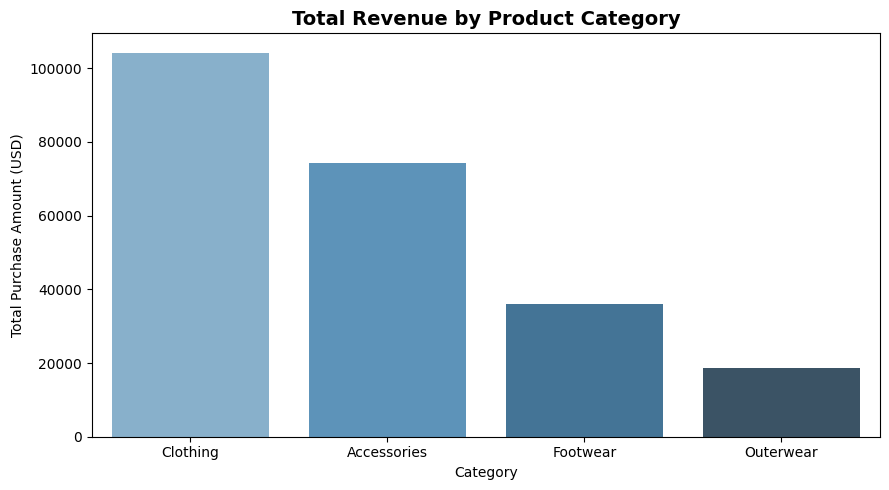

In [23]:
cat_revenue = df.groupby('category')['purchase_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=cat_revenue.index, y=cat_revenue.values, palette='Blues_d')
plt.title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Purchase Amount (USD)')
plt.tight_layout()
plt.savefig('revenue_by_category.png', dpi=150)
plt.show()

# Purchase Amount Distribution (Histogram)

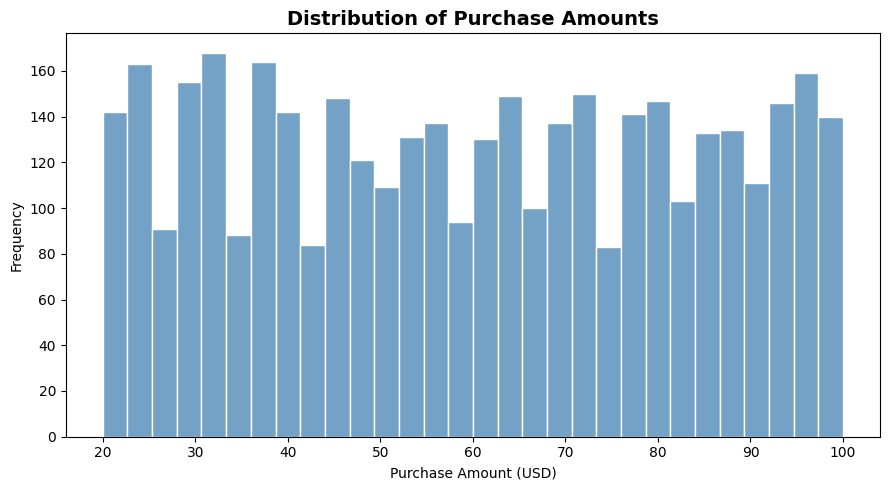

In [24]:
plt.figure(figsize=(9, 5))
sns.histplot(df['purchase_amount'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Purchase Amounts', fontsize=14, fontweight='bold')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('purchase_distribution.png', dpi=150)
plt.show()

# Average Rating by Age Group (Bar Chart)

C:\Users\kiransindam\AppData\Local\Temp\ipykernel_9580\900293048.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating = df.groupby('age_group')['review_rating'].mean().reindex(age_order)
C:\Users\kiransindam\AppData\Local\Temp\ipykernel_9580\900293048.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating.index, y=avg_rating.values, palette='coolwarm')


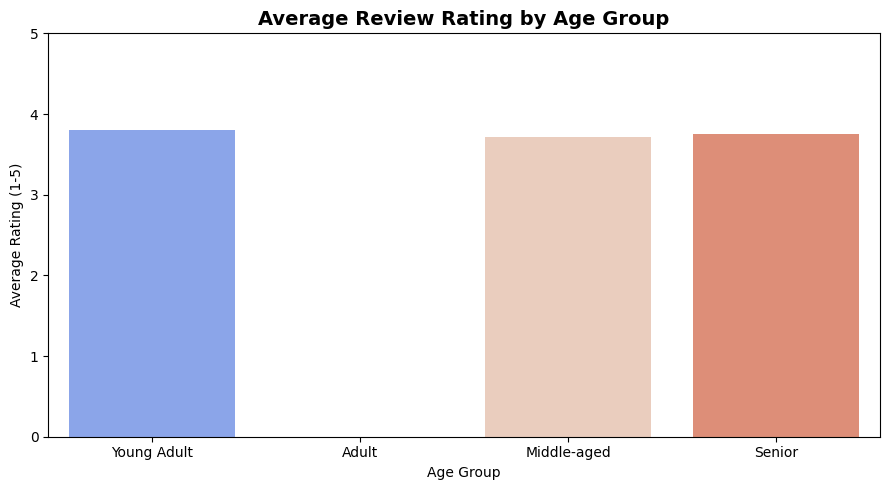

In [25]:
age_order = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
avg_rating = df.groupby('age_group')['review_rating'].mean().reindex(age_order)

plt.figure(figsize=(9, 5))
sns.barplot(x=avg_rating.index, y=avg_rating.values, palette='coolwarm')
plt.title('Average Review Rating by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Average Rating (1-5)')
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig('rating_by_age.png', dpi=150)
plt.show()

# Seasonal Sales Trend (Box Plot)

C:\Users\kiransindam\AppData\Local\Temp\ipykernel_9580\2506998627.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y='purchase_amount',


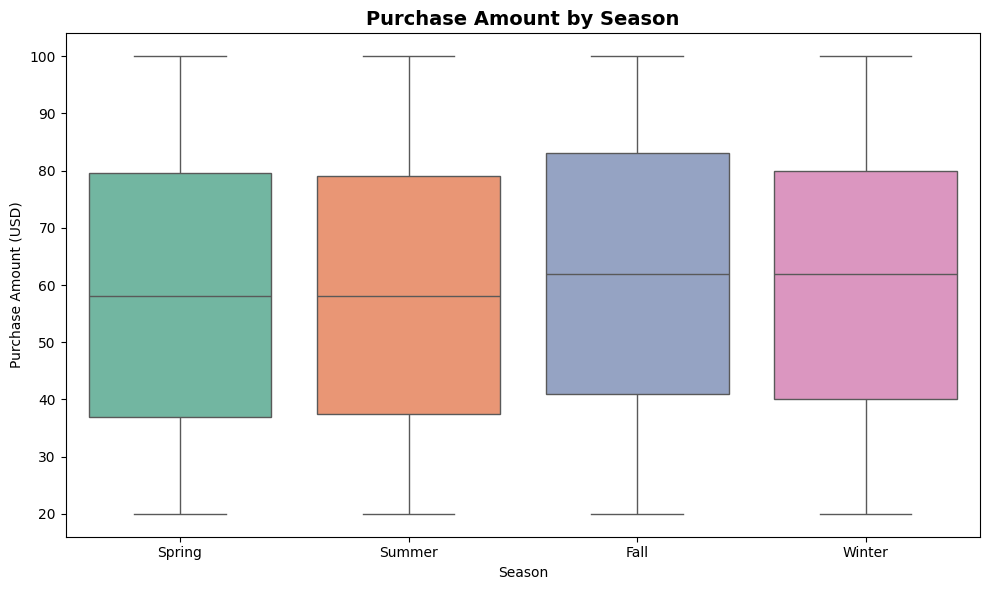

In [26]:
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='season', y='purchase_amount',
            order=season_order, palette='Set2')
plt.title('Purchase Amount by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Purchase Amount (USD)')
plt.tight_layout()
plt.savefig('seasonal_sales.png', dpi=150)
plt.show()

# Payment Method Breakdown (Pie Chart)

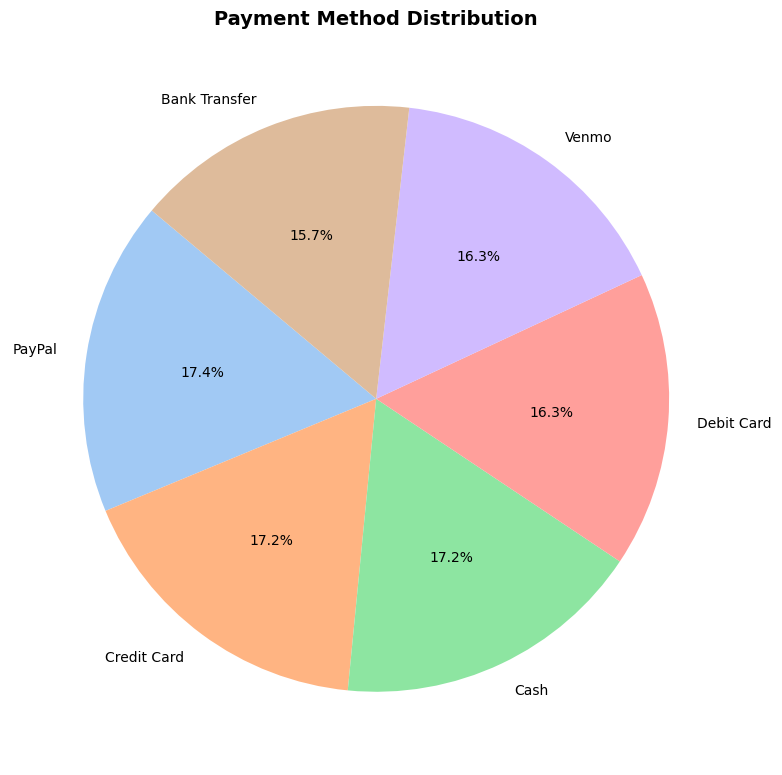

In [27]:
pay_counts = df['payment_method'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(pay_counts.values, labels=pay_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Payment Method Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('payment_methods.png', dpi=150)
plt.show()

# Gender vs Purchase Amount (Grouped Bar)

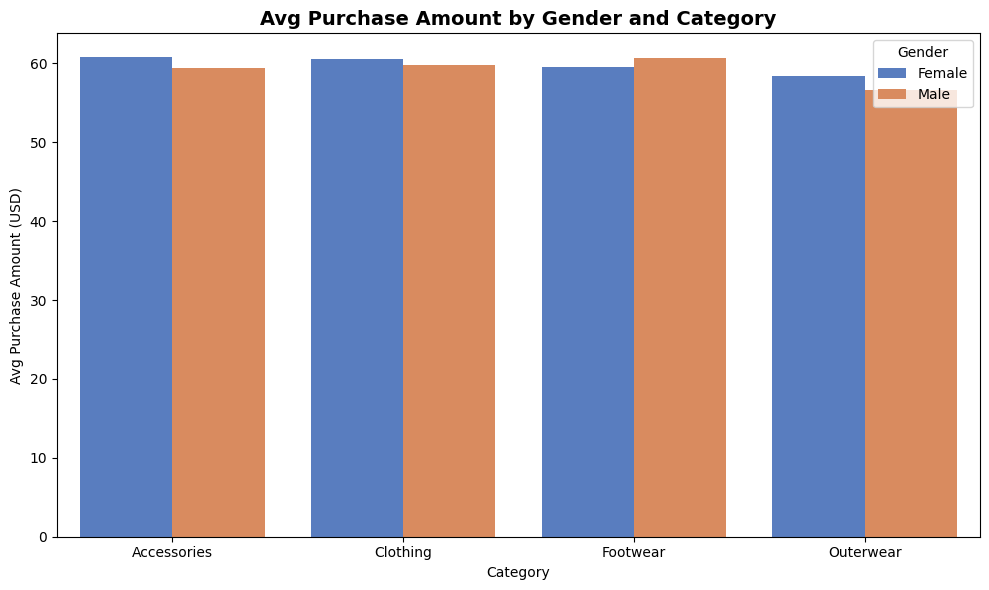

In [28]:
gender_cat = df.groupby(['gender', 'category'])['purchase_amount'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=gender_cat, x='category', y='purchase_amount',
            hue='gender', palette='muted')
plt.title('Avg Purchase Amount by Gender and Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Avg Purchase Amount (USD)')
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('gender_category.png', dpi=150)
plt.show()

# Correlation Heatmap

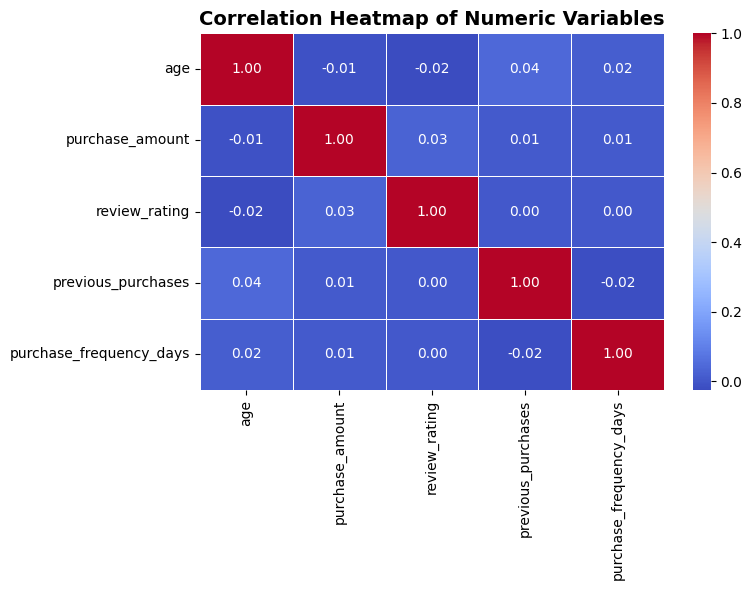

In [29]:
numeric_cols = ['age', 'purchase_amount', 'review_rating',
                'previous_purchases', 'purchase_frequency_days']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()